# Teste do Módulo `features_extraction`

Este notebook testa todas as funcionalidades do módulo `features_extraction`, incluindo:
- Extração de features de camadas específicas
- Extração de features de todas as camadas
- Diferentes estratégias de pooling (cls, mean, max, token)
- Extração de metafeatures com PyMFE
- Gerenciamento de dispositivos
- Configurações customizadas


## 1. Setup e Imports


In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import sys
import os
import logging
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Adicionar o diretório pai ao path para importar o módulo
sys.path.insert(0, os.path.abspath('..'))

from features_extraction import (
    FeaturesExtraction,
    ExtractionConfig,
    MetaFeatureConfig,
    DeviceManager,
)
from features_extraction.utils import setup_logging
from features_extraction.pooling import POOLING_STRATEGIES

# Configurar logging
setup_logging(level=logging.INFO)

# Configurar estilo de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports realizados com sucesso!")


/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports realizados com sucesso!


## 2. Configuração Inicial


In [5]:
# Verificar dispositivo disponível
device_info = DeviceManager.get_device_info()
print("📱 Informações do Dispositivo:")
for key, value in device_info.items():
    print(f"  {key}: {value}")

device = DeviceManager.resolve("auto")
print(f"\n🎯 Dispositivo selecionado: {device}")


2025-12-15 12:25:22 [INFO] features_extraction.device: Auto-selected Apple MPS device


📱 Informações do Dispositivo:
  cuda_available: False
  cuda_device_count: 0
  mps_available: True

🎯 Dispositivo selecionado: mps


## 3.1 Fine-tuning do Modelo

Antes de extrair as metafeatures, vamos fazer o fine-tuning do modelo no dataset RTE para melhorar sua performance na tarefa específica.

In [ ]:
# Imports adicionais para fine-tuning
from transformers import (
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports para fine-tuning carregados!")

In [ ]:
# Carregar dataset completo para fine-tuning
print("📥 Carregando datasets de treino e validação...")

train_dataset = load_dataset("glue", "rte", split="train")
val_dataset = load_dataset("glue", "rte", split="validation")

print(f"✅ Datasets carregados:")
print(f"   Treino: {len(train_dataset)} exemplos")
print(f"   Validação: {len(val_dataset)} exemplos")
print(f"   Classes: {train_dataset.features['label'].num_classes}")
print(f"   Exemplo: {train_dataset[0]}")

In [ ]:
# Função de tokenização para o dataset
def tokenize_function(examples):
    """Tokeniza os pares de sentenças do RTE"""
    return tokenizer(
        examples["sentence1"],
        examples["sentence2"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

# Tokenizar datasets
print("🔄 Tokenizando datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Preparar datasets para o Trainer
tokenized_train = tokenized_train.remove_columns(['sentence1', 'sentence2', 'idx'])
tokenized_val = tokenized_val.remove_columns(['sentence1', 'sentence2', 'idx'])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

print("✅ Tokenização concluída!")
print(f"   Colunas do dataset: {tokenized_train.column_names}")

In [ ]:
# Função para calcular métricas
def compute_metrics(eval_pred):
    """Calcula accuracy, precision, recall e F1"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✅ Função de métricas definida!")

In [ ]:
# Configurar argumentos de treinamento
print("⚙️ Configurando parâmetros de treinamento...")

training_args = TrainingArguments(
    output_dir="./results_rte_finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",  # Desabilitar wandb, tensorboard, etc.
    save_total_limit=2,  # Manter apenas os 2 melhores checkpoints
)

# Data collator para padding dinâmico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("✅ Configuração concluída!")
print(f"   Épocas: {training_args.num_train_epochs}")
print(f"   Batch size (treino): {training_args.per_device_train_batch_size}")
print(f"   Batch size (validação): {training_args.per_device_eval_batch_size}")

In [ ]:
# Criar Trainer
print("🏋️ Criando Trainer...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer criado com sucesso!")
print(f"   Modelo: {model.__class__.__name__}")
print(f"   Dispositivo: {training_args.device}")

In [ ]:
# Executar fine-tuning
print("🚀 Iniciando fine-tuning...")
print("=" * 80)

train_result = trainer.train()

print("=" * 80)
print("✅ Fine-tuning concluído!")
print(f"\n📊 Resultados do treinamento:")
print(f"   Loss final: {train_result.training_loss:.4f}")
print(f"   Tempo de treinamento: {train_result.metrics['train_runtime']:.2f}s")
print(f"   Samples/segundo: {train_result.metrics['train_samples_per_second']:.2f}")

In [ ]:
# Avaliar modelo no conjunto de validação
print("📊 Avaliando modelo fine-tunado...")

eval_results = trainer.evaluate()

print("✅ Avaliação concluída!")
print(f"\n📈 Métricas no conjunto de validação:")
print(f"   Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"   Precision: {eval_results['eval_precision']:.4f}")
print(f"   Recall: {eval_results['eval_recall']:.4f}")
print(f"   F1-Score: {eval_results['eval_f1']:.4f}")
print(f"   Loss: {eval_results['eval_loss']:.4f}")

In [ ]:
# Salvar modelo fine-tunado
output_dir = "./roberta_rte_finetuned_best"
print(f"💾 Salvando modelo fine-tunado em {output_dir}...")

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("✅ Modelo salvo com sucesso!")
print(f"   Diretório: {output_dir}")

In [ ]:
# Visualizar histórico de treinamento
print("📈 Visualizando histórico de treinamento...")

# Extrair histórico de logs
log_history = trainer.state.log_history

# Separar métricas de treino e validação
train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

if len(train_logs) > 0 and len(eval_logs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot de Loss
    train_steps = [log['step'] for log in train_logs if 'loss' in log]
    train_loss = [log['loss'] for log in train_logs if 'loss' in log]
    eval_steps = [log['step'] for log in eval_logs]
    eval_loss = [log['eval_loss'] for log in eval_logs]
    
    axes[0].plot(train_steps, train_loss, label='Training Loss', marker='o')
    axes[0].plot(eval_steps, eval_loss, label='Validation Loss', marker='s')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot de Accuracy
    eval_acc = [log['eval_accuracy'] for log in eval_logs]
    axes[1].plot(eval_steps, eval_acc, label='Validation Accuracy', marker='s', color='green')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Gráficos salvos em 'training_history.png'")
else:
    print("⚠️ Histórico de treinamento não disponível")

In [ ]:
# Comparação: Modelo base vs Fine-tunado
print("🔬 Comparação de Performance")
print("=" * 80)

# Carregar modelo base para comparação
print("\n📥 Carregando modelo base (sem fine-tuning) para comparação...")
model_base = RobertaForSequenceClassification.from_pretrained("roberta-base")
trainer_base = Trainer(
    model=model_base,
    args=training_args,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

base_results = trainer_base.evaluate()

print("\n📊 Resultados Comparativos:")
print("-" * 80)
print(f"{'Métrica':<20} {'Modelo Base':<20} {'Fine-tunado':<20} {'Melhoria':<20}")
print("-" * 80)

metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1']
for metric in metrics_to_compare:
    base_val = base_results[f'eval_{metric}']
    tuned_val = eval_results[f'eval_{metric}']
    improvement = ((tuned_val - base_val) / base_val) * 100 if base_val > 0 else 0
    
    print(f"{metric.capitalize():<20} {base_val:<20.4f} {tuned_val:<20.4f} {improvement:>+19.2f}%")

print("-" * 80)
print(f"\n✅ O modelo fine-tunado será usado para extração de features!")
print(f"   Modelo atual: roberta-base fine-tuned no RTE")

# Limpar modelo base da memória
del model_base, trainer_base
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()

---

## 4. Testes com Modelo Fine-tunado

A partir daqui, todas as extrações de features e metafeatures serão feitas usando o **modelo fine-tunado** no dataset RTE.

In [ ]:
# Atualizar referência do modelo para o modelo fine-tunado
# O modelo já está fine-tunado no objeto 'model' do trainer
# Vamos garantir que estamos usando ele
model = trainer.model

print("✅ Modelo atualizado para versão fine-tunada")
print(f"   Modelo: {model.__class__.__name__}")
print(f"   Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Modo: Fine-tuned no RTE dataset")

## 3. Carregar Modelo e Dataset


In [6]:
# Carregar modelo e tokenizer pré-treinados
print("📥 Carregando modelo e tokenizer...")
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name)

print(f"✅ Modelo '{model_name}' carregado com sucesso!")
print(f"   Parâmetros: {sum(p.numel() for p in model.parameters()):,}")


📥 Carregando modelo e tokenizer...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Modelo 'roberta-base' carregado com sucesso!
   Parâmetros: 124,647,170


In [7]:
# Carregar dataset de exemplo (GLUE RTE)
print("📥 Carregando dataset GLUE RTE...")
dataset = load_dataset("glue", "rte", split="train[:100]")

print(f"✅ Dataset carregado: {len(dataset)} exemplos")
print(f"   Colunas: {dataset.column_names}")
print(f"\n📄 Exemplo do dataset:")
print(f"   Sentence 1: {dataset[0]['sentence1'][:80]}...")
print(f"   Sentence 2: {dataset[0]['sentence2'][:80]}...")
print(f"   Label: {dataset[0]['label']}")


📥 Carregando dataset GLUE RTE...
✅ Dataset carregado: 100 exemplos
   Colunas: ['sentence1', 'sentence2', 'label', 'idx']

📄 Exemplo do dataset:
   Sentence 1: No Weapons of Mass Destruction Found in Iraq Yet....
   Sentence 2: Weapons of Mass Destruction Found in Iraq....
   Label: 1


In [8]:
# Função de tokenização para o dataset RTE
def tokenize_rte(tokenizer, batch, max_length):
    """Tokeniza pares de sentenças para a tarefa RTE."""
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        padding="longest",
        truncation=True,
        max_length=max_length,
    )

print("✅ Função de tokenização definida")


✅ Função de tokenização definida


## 4. Teste 1: Extração de Features de Uma Camada Específica


In [9]:
print("🔬 Teste 1: Extração de features de uma camada específica\n")

# Criar extrator
extractor = FeaturesExtraction(model, tokenizer)

# Configurar extração
config = ExtractionConfig(
    batch_size=16,
    max_length=128,
    device="auto",
    pooling="cls",
    return_numpy=True
)

# Extrair features da camada classificadora
target_layer = model.classifier.dense
print(f"🎯 Camada alvo: {target_layer.__class__.__name__}")

features, labels = extractor.extract_features_from_layer(
    layer=target_layer,
    dataset=dataset,
    tokenize_fn=tokenize_rte,
    config=config
)

print(f"\n✅ Features extraídas com sucesso!")
print(f"   Shape das features: {features.shape}")
print(f"   Shape dos labels: {labels.shape}")
print(f"   Tipo: {type(features)}")
print(f"   Estatísticas: mean={features.mean():.4f}, std={features.std():.4f}")


2025-12-15 12:26:33 [INFO] features_extraction.core: Initialized FeaturesExtraction with model=RobertaForSequenceClassification, tokenizer=RobertaTokenizer
2025-12-15 12:26:33 [INFO] features_extraction.utils: Starting extract_features_from_layer
2025-12-15 12:26:33 [INFO] features_extraction.device: Auto-selected Apple MPS device


🔬 Teste 1: Extração de features de uma camada específica

🎯 Camada alvo: Linear


2025-12-15 12:26:34 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'label', 'labels'}, removing 3 columns
Tokenizing dataset:   0%|          | 0/100 [00:00<?, ? examples/s]Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' trunca


✅ Features extraídas com sucesso!
   Shape das features: (100, 768)
   Shape dos labels: (100,)
   Tipo: <class 'numpy.ndarray'>
   Estatísticas: mean=-0.0006, std=0.2338


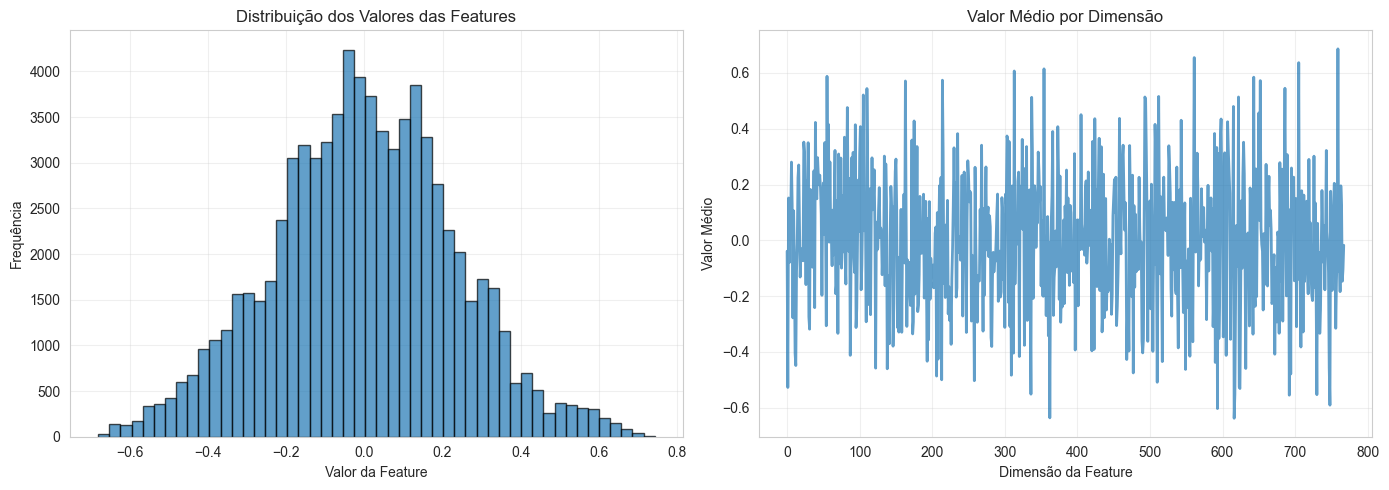

📊 Visualização gerada!


In [10]:
# Visualizar distribuição das features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de valores
axes[0].hist(features.flatten(), bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Valor da Feature')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Valores das Features')
axes[0].grid(True, alpha=0.3)

# Média das features por dimensão
mean_per_dim = features.mean(axis=0)
axes[1].plot(mean_per_dim, alpha=0.7, linewidth=2)
axes[1].set_xlabel('Dimensão da Feature')
axes[1].set_ylabel('Valor Médio')
axes[1].set_title('Valor Médio por Dimensão')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Visualização gerada!")


## 6. Teste 3: Extração de Todas as Camadas


In [13]:
print("🔬 Teste 3: Extração de features de todas as camadas\n")

# Usar dataset COMPLETO para extração de todas as camadas
full_dataset = load_dataset("glue", "rte", split="train")

# Configurar extração com salvamento automático
config = ExtractionConfig(
    batch_size=16,  # Batch maior para dataset completo
    max_length=128,
    device="auto",
    pooling="mean",
    return_numpy=True,
    output_path="../features_extraction/RTE_train_all_layers_features.npz"  # Salvar automaticamente
)

print(f"💾 Features serão salvas em: {config.output_path}")
print(f"📊 Dataset size: {len(full_dataset)} amostras\n")

features_by_layer, labels_all = extractor.extract_all_layers(
    dataset=full_dataset,
    tokenize_fn=tokenize_rte,
    config=config
)

print(f"\n✅ Features de todas as camadas extraídas e salvas!")
print(f"   Número de camadas: {len(features_by_layer)}")
print(f"   Labels shape: {labels_all.shape if labels_all is not None else None}")
print(f"   Arquivo salvo: {config.output_path}")
print(f"\n📋 Camadas extraídas:")
for layer_name, features_layer in list(features_by_layer.items())[:5]:
    print(f"   {layer_name}: {features_layer.shape}")
print(f"   ...")
for layer_name, features_layer in list(features_by_layer.items())[-2:]:
    print(f"   {layer_name}: {features_layer.shape}")

🔬 Teste 3: Extração de features de todas as camadas



2025-12-15 12:28:05 [INFO] features_extraction.utils: Starting extract_all_layers
2025-12-15 12:28:05 [INFO] features_extraction.device: Auto-selected Apple MPS device
2025-12-15 12:28:05 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'label', 'labels'}, removing 3 columns
Tokenizing dataset:   0%|          | 0/50 [00:00<?, ? examples/s]Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty ev


✅ Features de todas as camadas extraídas!
   Número de camadas: 13
   Labels shape: (50,)

📋 Camadas extraídas:
   embeddings: (50, 768)
   layer_0: (50, 768)
   layer_1: (50, 768)
   layer_2: (50, 768)
   layer_3: (50, 768)
   ...
   layer_10: (50, 768)
   layer_11: (50, 768)


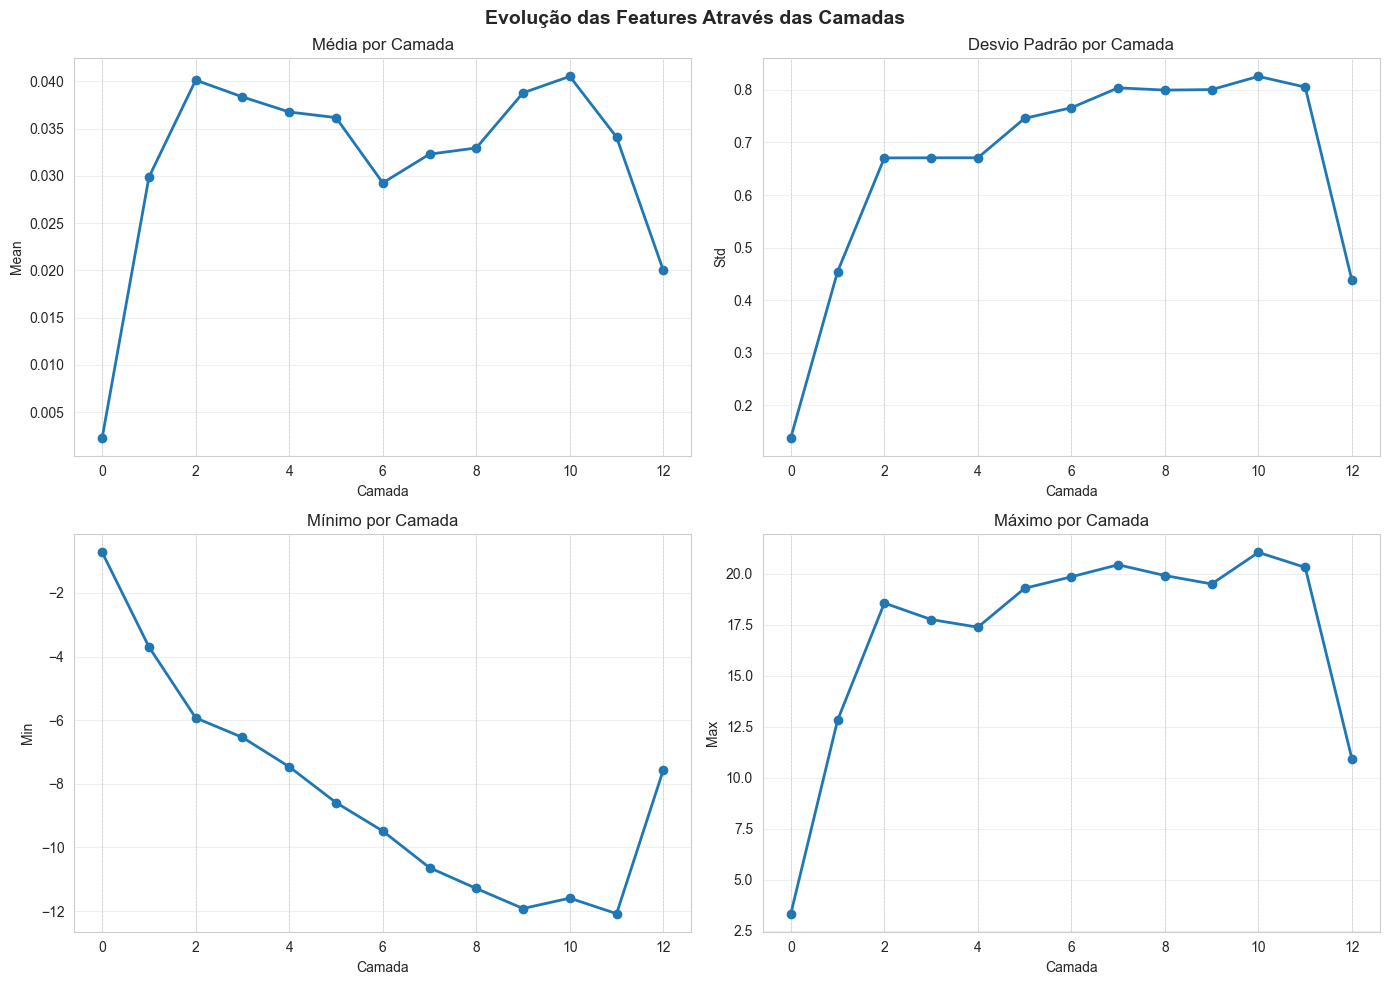

📊 Análise de camadas visualizada!


In [14]:
# Analisar como as features evoluem através das camadas
layer_stats = []
for layer_name, features_layer in features_by_layer.items():
    layer_stats.append({
        'layer': layer_name,
        'mean': features_layer.mean(),
        'std': features_layer.std(),
        'min': features_layer.min(),
        'max': features_layer.max()
    })

stats_df = pd.DataFrame(layer_stats)

# Visualizar estatísticas por camada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['mean', 'std', 'min', 'max']
titles = ['Média por Camada', 'Desvio Padrão por Camada', 'Mínimo por Camada', 'Máximo por Camada']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.plot(range(len(stats_df)), stats_df[metric], marker='o', linewidth=2, markersize=6)
    ax.set_xlabel('Camada')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Adicionar labels de camada em alguns pontos
    step = max(1, len(stats_df) // 5)
    for i in range(0, len(stats_df), step):
        ax.axvline(x=i, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

plt.suptitle('Evolução das Features Através das Camadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Análise de camadas visualizada!")


## 7. Teste 4: Extração de Metafeatures (Opcional - pode demorar)


In [15]:
print("🔬 Teste 4: Extração de metafeatures com PyMFE\n")

# Configurações para extração
extraction_config = ExtractionConfig(
    batch_size=16,
    max_length=128,
    device="auto",
    pooling="cls",
    return_numpy=True
)

meta_config = MetaFeatureConfig(
    groups=["statistical", "info-theory", "complexity"],  # Grupos mais rápidos
    summaries=["mean", "sd"],
    dataset_name="rte_test",
    token_reduce="mean"
)

meta_df = extractor.extract_all_layers_and_metafeatures(
    dataset=small_dataset,
    tokenize_fn=tokenize_rte,
    extraction_config=extraction_config,
    meta_config=meta_config
)

print(f"\n✅ Metafeatures extraídas!")
print(f"   Shape do DataFrame: {meta_df.shape}")
print(f"   Colunas: {list(meta_df.columns)}")
print(f"   Grupos: {meta_df['group'].unique().tolist()}")
print(f"   Camadas: {meta_df['layer'].unique().tolist()}")


2025-12-15 12:31:56 [INFO] features_extraction.utils: Starting extract_all_layers_and_metafeatures
2025-12-15 12:31:56 [INFO] features_extraction.utils: Starting extract_all_layers
2025-12-15 12:31:56 [INFO] features_extraction.device: Auto-selected Apple MPS device
2025-12-15 12:31:56 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'label', 'labels'}, removing 3 columns


🔬 Teste 4: Extração de metafeatures com PyMFE



2025-12-15 12:31:57 [INFO] features_extraction.tokenizer: Tokenization complete. Dataset has 50 examples, columns: ['label', 'input_ids', 'attention_mask']
2025-12-15 12:31:57 [INFO] features_extraction.core: Extracting all layers with pooling=cls
2025-12-15 12:31:57 [INFO] features_extraction.core: Found 13 layers: ['embeddings', 'layer_0', 'layer_1']...layer_11
2025-12-15 12:31:58 [INFO] features_extraction.utils: Completed extract_all_layers in 1.07s
2025-12-15 12:31:58 [INFO] features_extraction.core: Extracting meta-features for 13 layers
2025-12-15 12:31:58 [INFO] features_extraction.metafeatures: Extracting meta-features: X.shape=(50, 768), y.shape=(50,), groups=['statistical', 'info-theory', 'complexity']
2025-12-15 12:31:58 [INFO] features_extraction.metafeatures: Extracting 3 meta-feature groups
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn


✅ Metafeatures extraídas!
   Shape do DataFrame: (1235, 5)
   Colunas: ['feature', 'value', 'group', 'dataset', 'layer']
   Grupos: ['statistical', 'info-theory', 'complexity']
   Camadas: ['embeddings', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'layer_11']


In [16]:
# Visualizar as primeiras metafeatures
print("\n📋 Primeiras 15 metafeatures:")
display(meta_df.head(15))



📋 Primeiras 15 metafeatures:


,feature,value,group,dataset,layer
0,can_cor.mean,NaN,statistical,rte_test,embeddings
1,can_cor.sd,NaN,statistical,rte_test,embeddings
2,cor.mean,NaN,statistical,rte_test,embeddings
3,cor.sd,NaN,statistical,rte_test,embeddings
4,cov.mean,0.0,statistical,rte_test,embeddings
5,cov.sd,0.0,statistical,rte_test,embeddings
6,eigenvalues.mean,0.0,statistical,rte_test,embeddings
7,eigenvalues.sd,0.0,statistical,rte_test,embeddings
8,g_mean.mean,0.0,statistical,rte_test,embeddings
9,g_mean.sd,0.0,statistical,rte_test,embeddings


In [24]:

meta_df[meta_df.isna().any(axis=1)]

# Mostrar quantas linhas com NaN cada metafeature representa
na_counts = meta_df[meta_df.isna().any(axis=1)].groupby('feature').size().reset_index(name='count')
na_counts


,feature,count
0,can_cor.mean,1
1,can_cor.sd,13
2,cor.mean,1
3,cor.sd,1
4,f1.mean,1
5,f1.sd,1
6,f1v.mean,1
7,f1v.sd,13
8,f2.mean,1
9,f2.sd,13


In [29]:
meta_df[meta_df["feature"].str.contains("f1")]

,feature,value,group,dataset,layer
65,f1.mean,NaN,complexity,rte_test,embeddings
66,f1.sd,NaN,complexity,rte_test,embeddings
67,f1v.mean,NaN,complexity,rte_test,embeddings
68,f1v.sd,NaN,complexity,rte_test,embeddings
160,f1.mean,0.981635,complexity,rte_test,layer_0
161,f1.sd,0.023029,complexity,rte_test,layer_0
162,f1v.mean,0.271362,complexity,rte_test,layer_0
163,f1v.sd,NaN,complexity,rte_test,layer_0
255,f1.mean,0.981736,complexity,rte_test,layer_1
256,f1.sd,0.026106,complexity,rte_test,layer_1


In [ ]:
meta_df[meta_df["feature"].str.contains("f1.mean")]

,feature,value,group,dataset,layer
65,f1.mean,NaN,complexity,rte_test,embeddings
160,f1.mean,0.981635,complexity,rte_test,layer_0
255,f1.mean,0.981736,complexity,rte_test,layer_1
350,f1.mean,0.985186,complexity,rte_test,layer_2
445,f1.mean,0.986951,complexity,rte_test,layer_3
540,f1.mean,0.987163,complexity,rte_test,layer_4
635,f1.mean,0.987298,complexity,rte_test,layer_5
730,f1.mean,0.985667,complexity,rte_test,layer_6
825,f1.mean,0.988066,complexity,rte_test,layer_7
920,f1.mean,0.988910,complexity,rte_test,layer_8


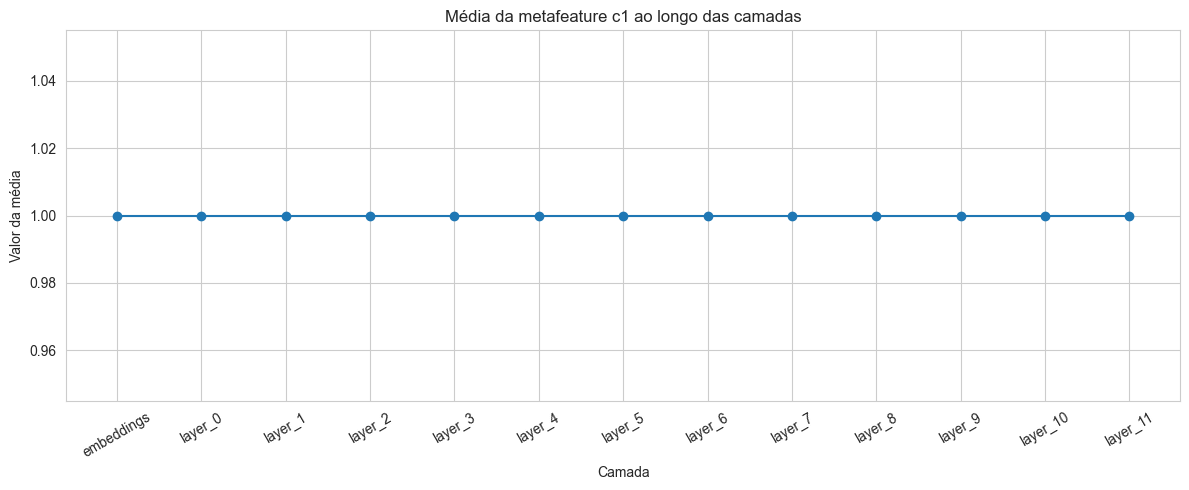

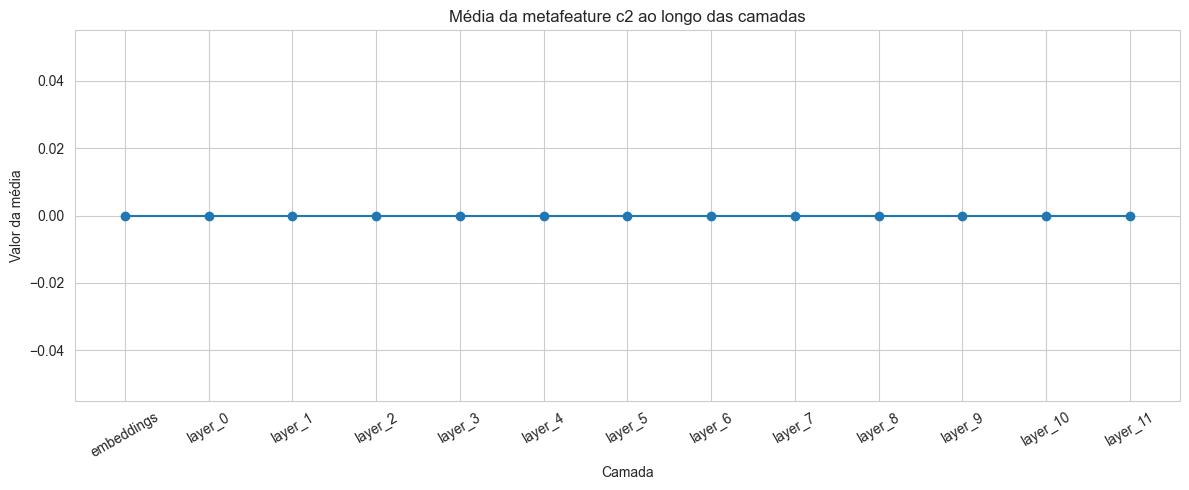

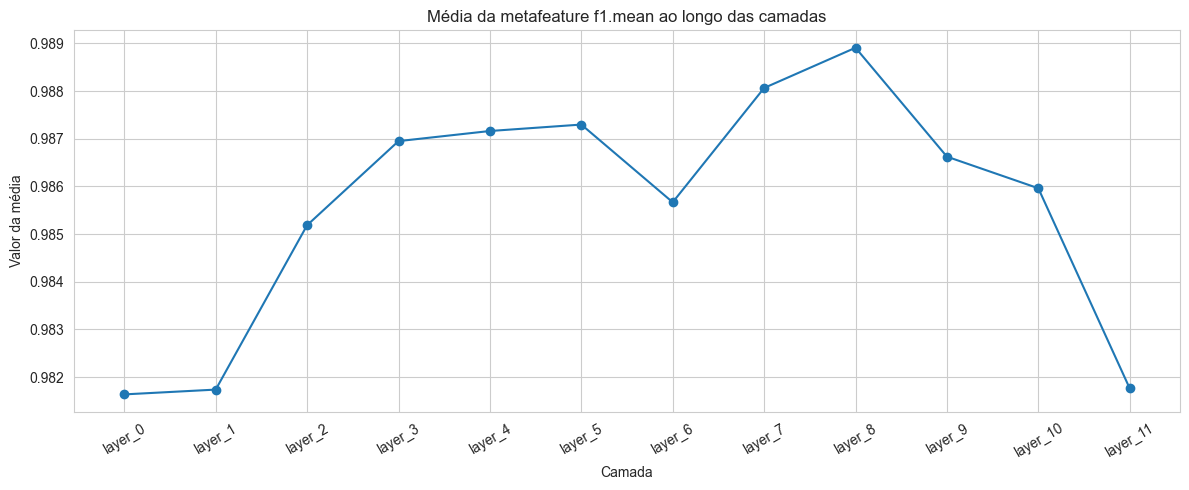

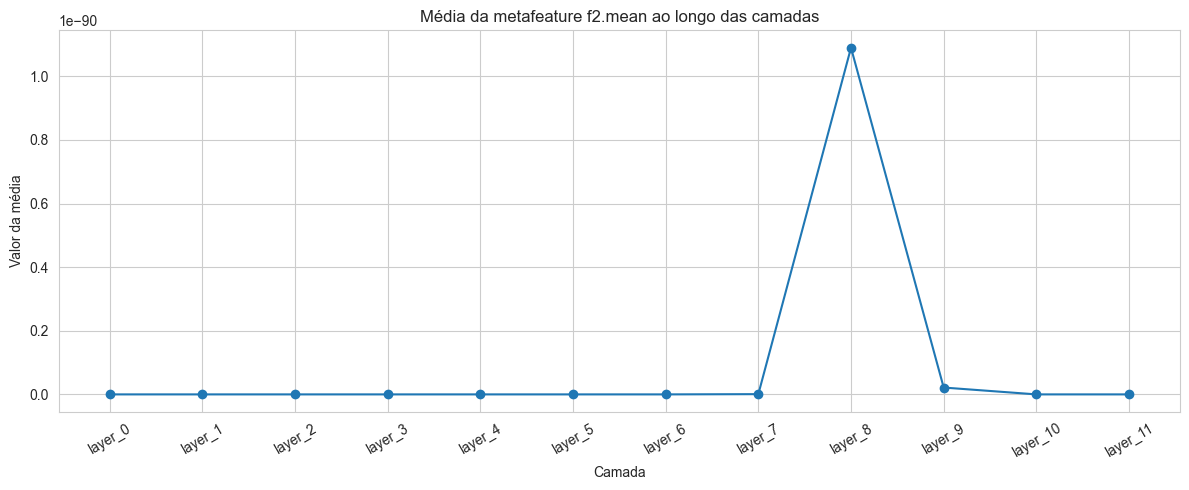

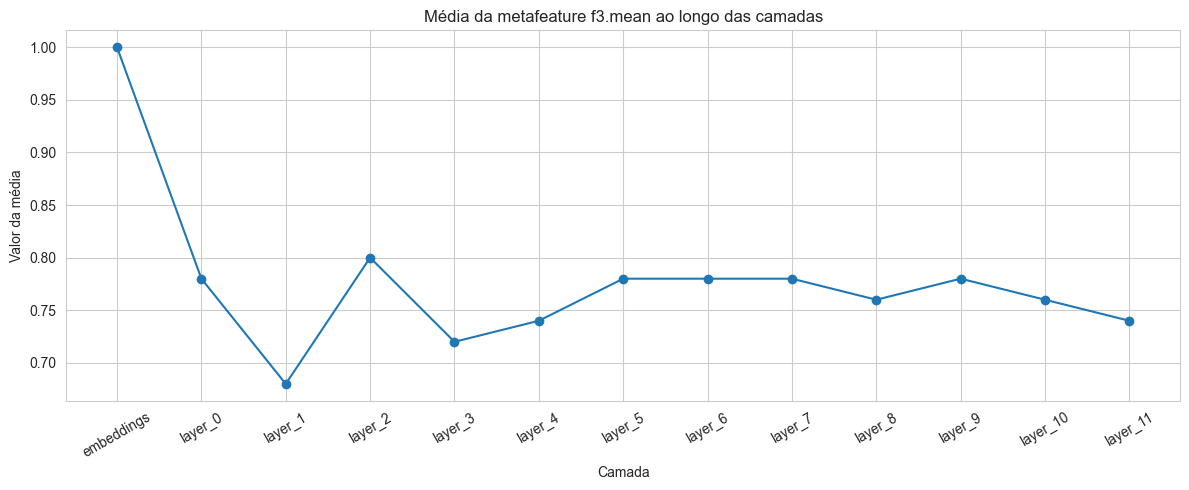

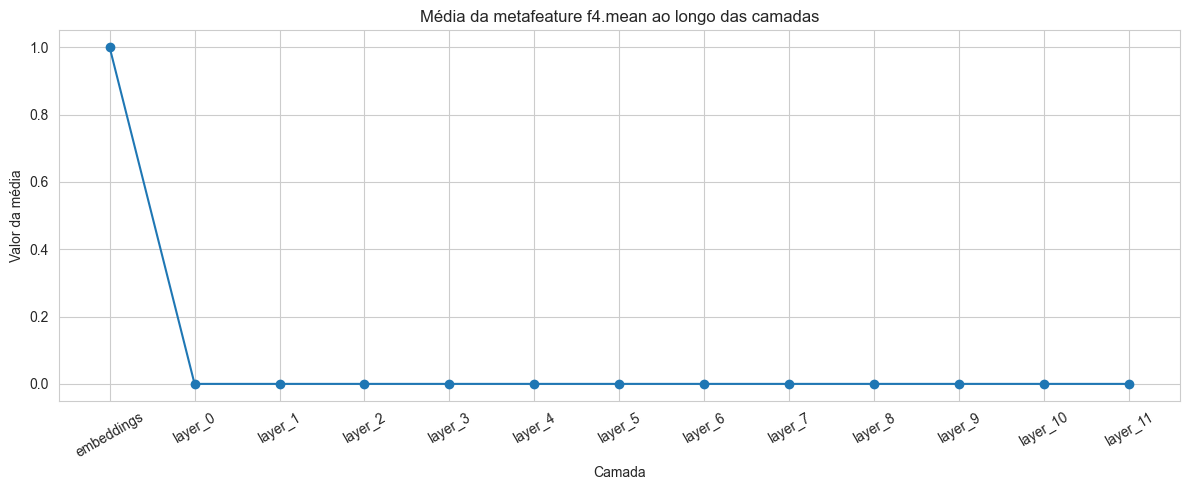

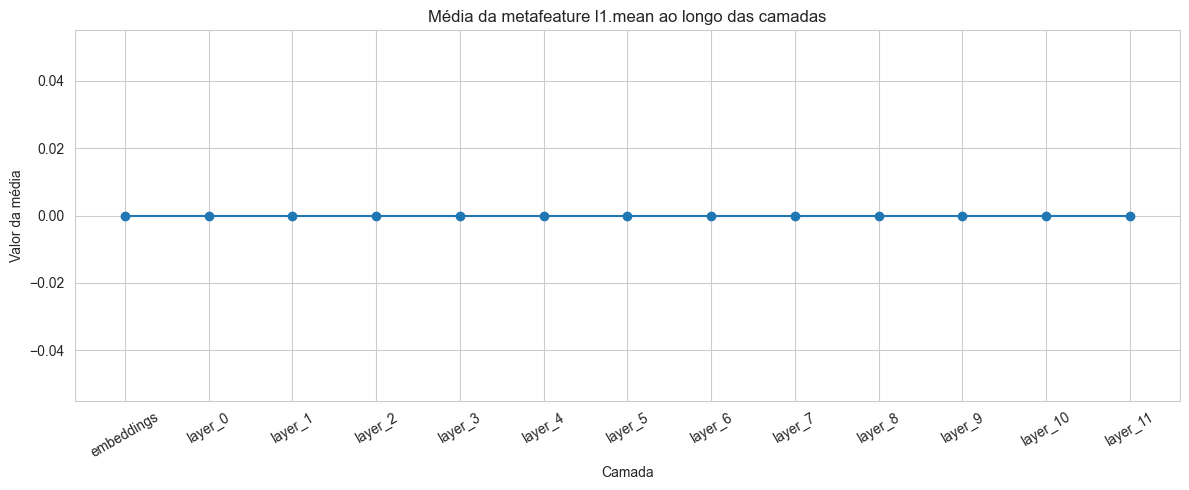

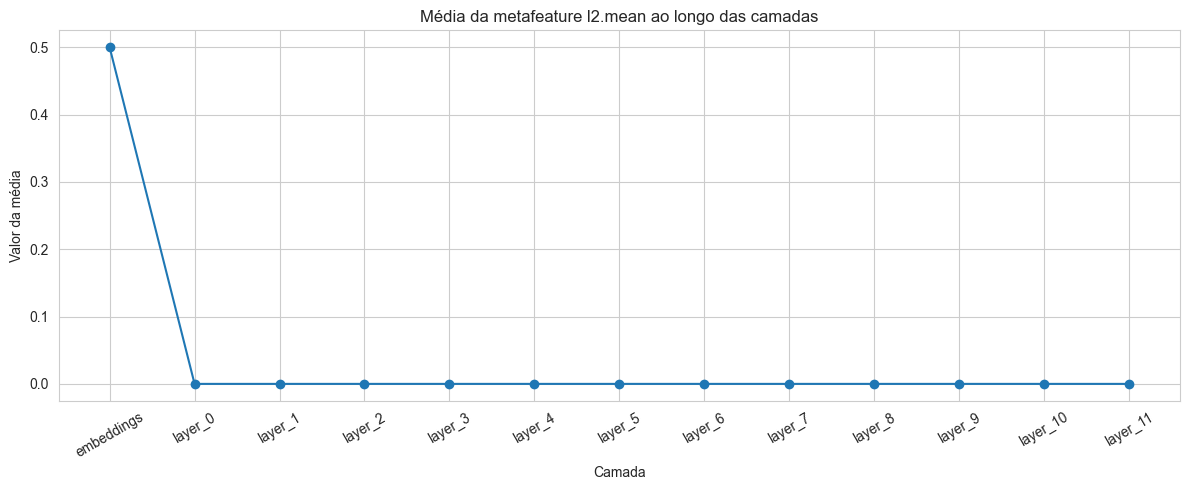

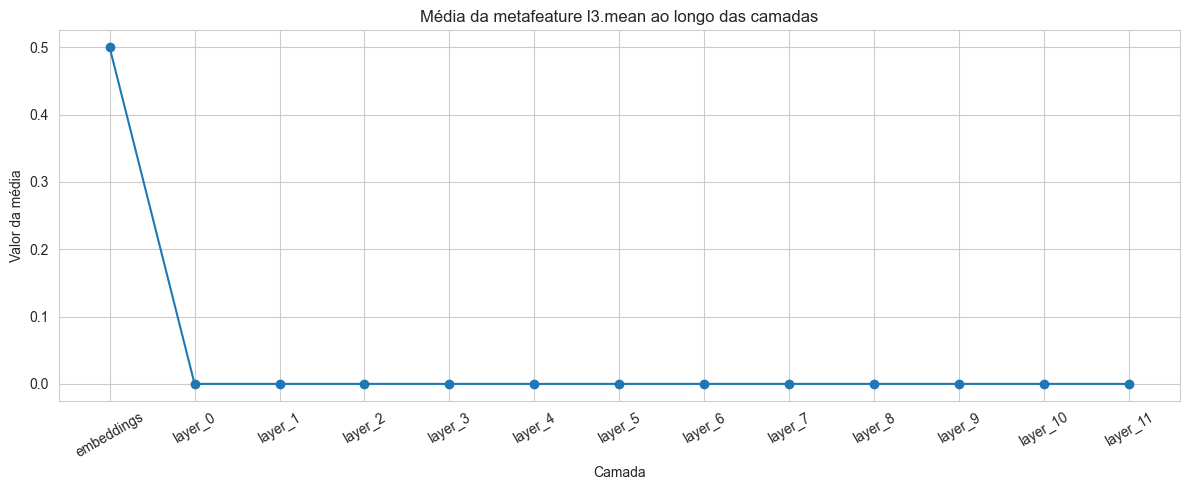

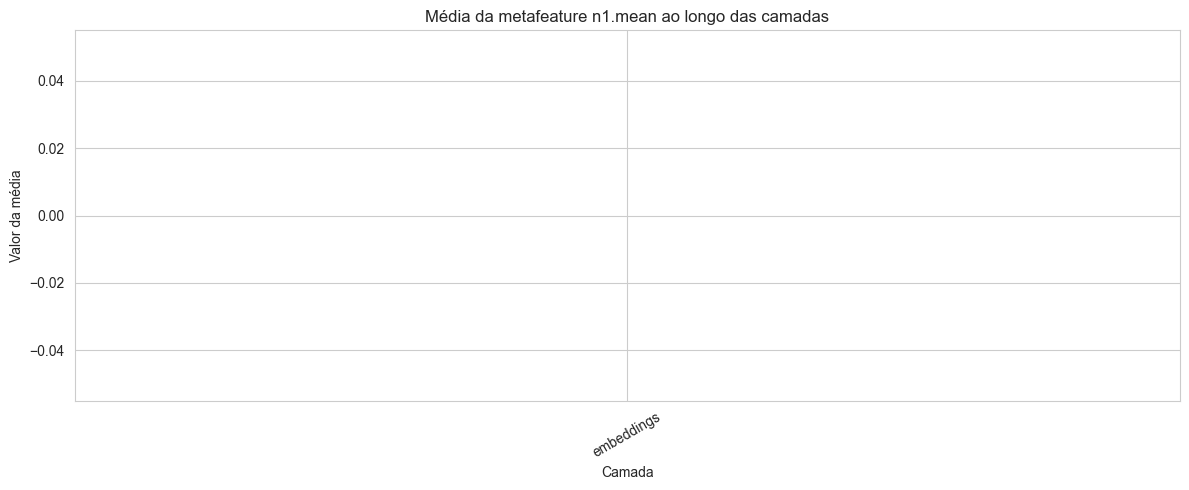

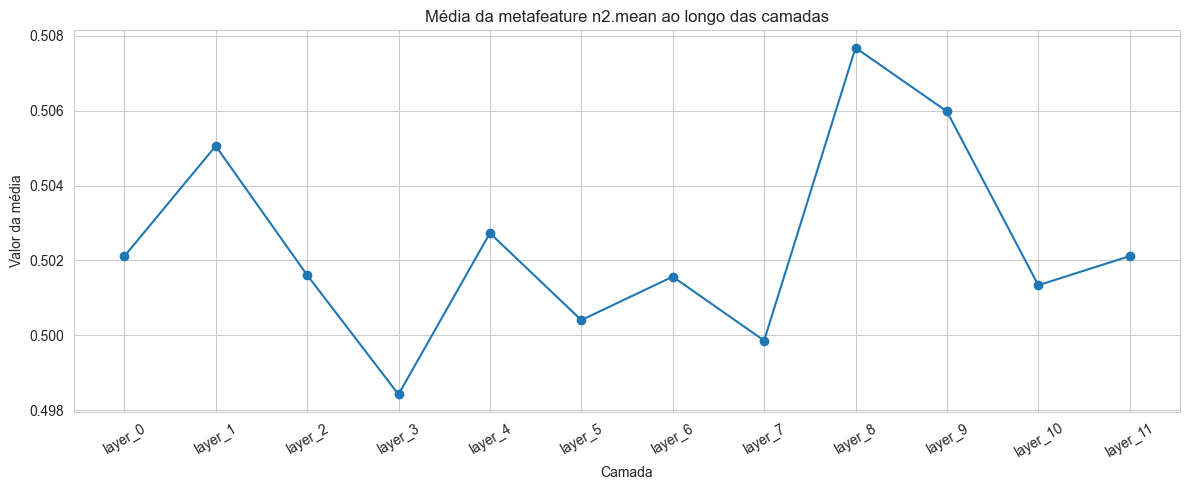

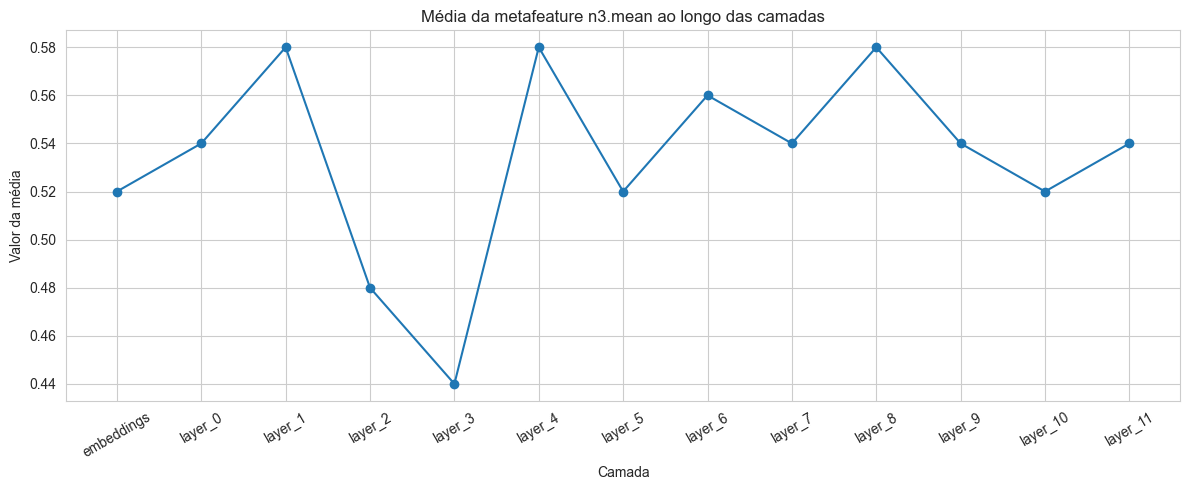

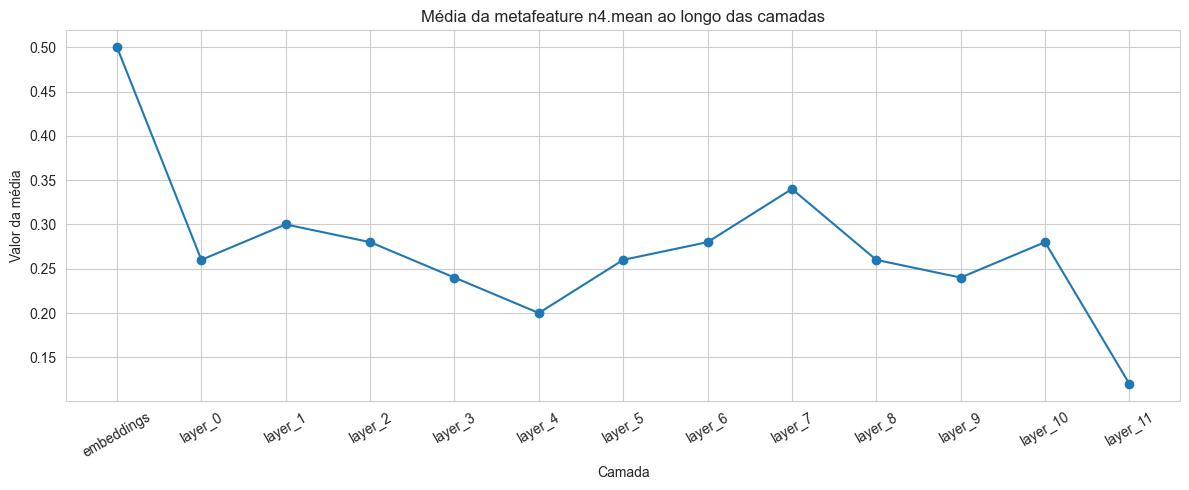

In [ ]:
import matplotlib.pyplot as plt

# Lista das features solicitadas
features_to_plot = ["c1", "c2", "f1.mean", "f2.mean", "f3.mean", "f4.mean", "l1.mean", "l2.mean", "l3.mean", "n1.mean", "n2.mean", "n3.mean", "n4.mean"]

# Filtrar apenas as linhas com .mean das features desejadas
meta_means = meta_df[
    meta_df["feature"].isin([f"{feat}" for feat in features_to_plot])
].copy()

# Garantir que as camadas estejam em ordem correta
layer_order = (
    meta_means["layer"].drop_duplicates().sort_values(key=lambda x: x.str.extract(r'(\d+)').fillna(-1).astype(int)[0])
)

for feat in features_to_plot:
    plt.figure(figsize=(12, 5))
    feat_row = meta_means[meta_means["feature"] == f"{feat}"]
    # Para garantir consistência, faz um merge para ter todas as camadas, mesmo se faltar alguma
    feat_row = layer_order.to_frame().merge(feat_row, on="layer", how="left")
    plt.plot(
        feat_row["layer"],
        feat_row["value"],
        marker='o'
    )
    plt.title(f"Média da metafeature {feat} ao longo das camadas")
    plt.xlabel("Camada")
    plt.ylabel("Valor da média")
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
